# Development of a CNN Model with the Spectogram as it's input feature:

## Imports:

In [2]:
import tensorflow as tf
from scipy.fft import fft
import os
import scipy.io.wavfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import random
import librosa
import librosa.display

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Generating Spectograms:

Arquivo aleatório selecionado: dataset/train/go/go_1050.wav
Shape do Espectrograma Logarítmico: (1025, 32)


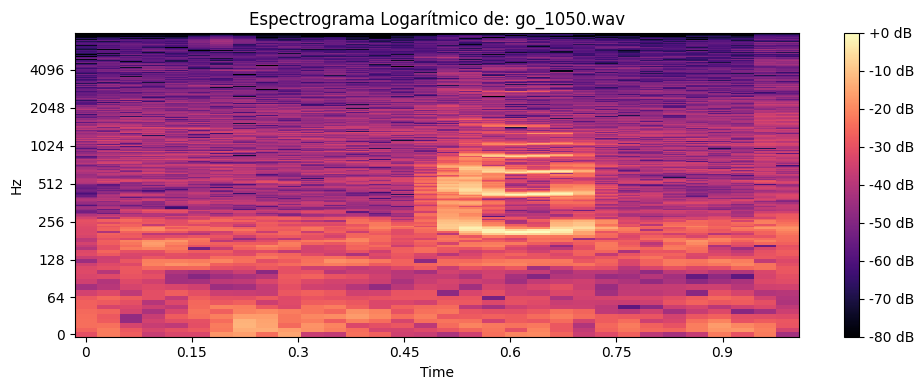

In [4]:
TRAIN_PATH = 'dataset/train'

random_class = random.choice(os.listdir(TRAIN_PATH))
class_path = os.path.join(TRAIN_PATH, random_class)

random_wav_file = random.choice([f for f in os.listdir(class_path) if f.endswith('.wav')])
file_path = os.path.join(class_path, random_wav_file)
print(f"Arquivo aleatório selecionado: {file_path}")

audio, sr = librosa.load(file_path, sr=None)

stft_result = librosa.stft(audio)

amplitude_spectrogram = np.abs(stft_result)

log_spectrogram = librosa.amplitude_to_db(amplitude_spectrogram, ref=np.max)

print(f"Shape do Espectrograma Logarítmico: {log_spectrogram.shape}")

plt.figure(figsize=(10, 4))
librosa.display.specshow(log_spectrogram, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Espectrograma Logarítmico de: {random_wav_file}')
plt.tight_layout()
plt.show()

In [5]:
SAMPLE_RATE = 16000
DURATION = 1
SAMPLES_PER_AUDIO = SAMPLE_RATE * DURATION

PATHS = {
    'train': 'dataset/train',
    'validation': 'dataset/validation',
    'test': 'dataset/test'
}

def create_spectrograms(data_path):
    spectrograms = []
    labels = []
    
    try:
        classes = sorted(os.listdir(data_path))
    except FileNotFoundError:
        print(f"AVISO: Diretório não encontrado em '{data_path}'. Pulando.")
        return np.array([]), np.array([])
        
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        if not os.path.isdir(class_path):
            continue
            
        print(f"  Processando classe: {class_name}")
        for file_name in os.listdir(class_path):
            if file_name.endswith('.wav'):
                file_path = os.path.join(class_path, file_name)
                
                # Carrega o áudio
                audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
                
                # Padroniza o tamanho do áudio (padding ou truncagem)
                if len(audio) < SAMPLES_PER_AUDIO:
                    audio = np.pad(audio, (0, SAMPLES_PER_AUDIO - len(audio)), mode='constant')
                else:
                    audio = audio[:SAMPLES_PER_AUDIO]
                
                # Gera o espectrograma logarítmico
                stft_result = librosa.stft(audio)
                amplitude_spectrogram = np.abs(stft_result)
                log_spectrogram = librosa.amplitude_to_db(amplitude_spectrogram, ref=np.max)
                
                spectrograms.append(log_spectrogram)
                labels.append(class_name)
                
    return np.array(spectrograms), np.array(labels)

print("Iniciando pré-processamento para o conjunto de TREINO...")
X_train, y_train = create_spectrograms(PATHS['train'])

print("\nIniciando pré-processamento para o conjunto de VALIDAÇÃO...")
X_val, y_val = create_spectrograms(PATHS['validation'])

print("\nIniciando pré-processamento para o conjunto de TESTE...")
X_test, y_test = create_spectrograms(PATHS['test'])

print("\n--- Processamento concluído ---")

# --- Preparação Final para a CNN ---

# 1. Adicionar o canal de cor (necessário para CNNs)
# Formato original: (n_amostras, n_frequencias, n_frames)
# Novo formato: (n_amostras, n_frequencias, n_frames, 1)
X_train_espectograma = X_train[..., np.newaxis]
X_val_espectograma = X_val[..., np.newaxis]
X_test_espectograma = X_test[..., np.newaxis]

# 2. Codificar os labels para o formato one-hot
label_encoder = LabelEncoder()
y_train_hot_espectograma = tf.keras.utils.to_categorical(label_encoder.fit_transform(y_train))
y_val_hot_espectograma = tf.keras.utils.to_categorical(label_encoder.transform(y_val))
y_test_hot_espectograma = tf.keras.utils.to_categorical(label_encoder.transform(y_test))

print(f"\nShape de X_train_espectograma  pronto para a CNN: {X_train.shape}")
print(f"Shape de y_train_hot_espectograma  pronto para a CNN: {y_train_hot_espectograma.shape}")
print(f"Shape de X_val_espectograma  pronto para a CNN: {X_val.shape}")
print(f"Shape de y_val_hot_espectograma  pronto para a CNN: {y_val_hot_espectograma.shape}")
print(f"Shape de X_test_espectograma  pronto para a CNN: {X_test.shape}")
print(f"Shape de y_test_hot_espectograma  pronto para a CNN: {y_test_hot_espectograma.shape}")

Iniciando pré-processamento para o conjunto de TREINO...
  Processando classe: _silence_
  Processando classe: _unknown_
  Processando classe: go
  Processando classe: no
  Processando classe: off
  Processando classe: on
  Processando classe: stop

Iniciando pré-processamento para o conjunto de VALIDAÇÃO...
  Processando classe: _silence_
  Processando classe: _unknown_
  Processando classe: go
  Processando classe: no
  Processando classe: off
  Processando classe: on
  Processando classe: stop

Iniciando pré-processamento para o conjunto de TESTE...
  Processando classe: _silence_
  Processando classe: _unknown_
  Processando classe: go
  Processando classe: no
  Processando classe: off
  Processando classe: on
  Processando classe: stop

--- Processamento concluído ---

Shape de X_train_espectograma  pronto para a CNN: (19201, 1025, 32)
Shape de y_train_hot_espectograma  pronto para a CNN: (19201, 7)
Shape de X_val_espectograma  pronto para a CNN: (2391, 1025, 32)
Shape de y_val_ho

## Training:

In [6]:
input_shape = X_train_espectograma.shape[1:]
input_shape

(1025, 32, 1)

In [11]:
model_espectograma = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_espectograma.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 1025, 32, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1025, 32, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 512, 16, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 512, 16, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512, 16, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 256, 8, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 8, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 8, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 4, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,817,223 (129.00 MB)

 Trainable params: 33,814,983 (128.99 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [12]:
model_espectograma.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [ ]:
history = model_espectograma.fit(X_train_espectograma, y_train_hot_espectograma, validation_data=(X_val_espectograma, y_val_hot_espectograma),
                                callbacks = callbacks, epochs=100, batch_size=32,verbose=1)

Epoch 1/100


I0000 00:00:1758250355.099785    9662 service.cc:152] XLA service 0x747e700156f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758250355.099806    9662 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-18 23:52:35.141078: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758250355.377693    9662 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/601 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.1714 - loss: 2.9106

I0000 00:00:1758250358.380835    9662 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.4879 - loss: 1.4078 - val_accuracy: 0.4500 - val_loss: 2.4385
Epoch 2/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.6339 - loss: 0.9614 - val_accuracy: 0.6290 - val_loss: 1.0860
Epoch 3/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6887 - loss: 0.8275 - val_accuracy: 0.7373 - val_loss: 0.7049
Epoch 4/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7228 - loss: 0.7424 - val_accuracy: 0.6780 - val_loss: 0.8755
Epoch 5/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7522 - loss: 0.6699 - val_accuracy: 0.5320 - val_loss: 1.2558
Epoch 6/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7752 - loss: 0.6061 - val_accuracy: 0.6629 - val_loss: 0.9543
Epoch 7/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7838 - loss: 0.5907 - val_accuracy: 0.5245 - val_loss: 1.5303
Epoch 8/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8026 - loss: 0.5416 - val_

## Testing and Results:

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
y_pred_probs = model_espectograma.predict(X_test_espectograma)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.argmax(y_test_hot_espectograma, axis=1)

In [ ]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=label_encoder.classes_)

print(report)

In [ ]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

## Extra:

In [ ]:
# to do

In [ ]:
model_espectograma_CNN_1 = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Conv1D(32, 3),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(64, 3),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 3),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation='softmax')
])

model_espectograma_CNN_1.summary()